In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
import os
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT_NAME"] = "Agentic RAG Project"

In [5]:
from langchain_tavily import TavilySearch



# Initialize the tool
tavily_tool = TavilySearch(
    max_results=5
)


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [ ]:
#from langchain_groq import ChatGroq
#llm=ChatGroq(model_name="Gemma2-9b-It")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0.3)
#gemini-3.1-flash-lite

In [8]:
urls=["https://www.mea.gov.in/Images/pdf1/Part1.pdf",
      "https://www.mea.gov.in/Images/pdf1/Part2.pdf"]

In [9]:
docs=[WebBaseLoader(url).load()for url in urls]

In [10]:
docs_list=[item for sublist in docs for item in sublist]

In [11]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=10)
texts=text_splitter.split_documents(docs_list)

In [12]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

In [13]:
vectorstore=Chroma.from_documents(
    documents=texts,
    collection_name="MEA_Govt_of_india",
    embedding=embeddings)

In [14]:
# 3. Setup Lexical Keyword Retriever (BM25)
bm25_retriever = BM25Retriever.from_documents(texts)
bm25_retriever.k = 3

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

# 4. Combine into an Ensemble Retriever
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.3, 0.7] # Balance between keyword and vector results
)

In [15]:
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_classic.retrievers import ContextualCompressionRetriever

In [16]:

# Initialize the Ranker client first
flashrank_client = Ranker(model_name="ms-marco-MiniLM-L-12-v2")

# Pass the client explicitly to bypass the validation bug
compressor = FlashrankRerank(client=flashrank_client, top_n=3)
# 2. Initialize the FlashRank compressor
#compressor = FlashrankRerank(top_n=3)

# 3. Create the Compression Retriever
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, 
    base_retriever=ensemble_retriever
)

INFO:flashrank.Ranker:Downloading ms-marco-MiniLM-L-12-v2...
ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:03<00:00, 7.26MiB/s]


In [17]:
retriever_tool = create_retriever_tool(
    name="MEA_Retriever",
    retriever=compression_retriever,
    description="Useful for answering questions about the Ministry of External Affairs of the Government of India."
)

In [107]:
tools = [retriever_tool,tavily_tool]
tool_node=ToolNode(tools)
llm_with_tools=llm.bind_tools(tools)

In [19]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
from langchain_core.messages import  SystemMessage,HumanMessage
def ai_assistant(state:AgentState):
    print("---CALL AGENT---")
    messages = state['messages']
    print(f"this is my message: {messages}")
    
    if len(messages)>1:
        response=llm.invoke(messages[-1].content)
        return {"messages": [response]}
    else:
        messages={[SystemMessage(content="""You are a helpful AI assistant whose goal is to answer the user's question based on the following conditions:
        1. If the user's question is about the Ministry of External Affairs of the Government of India, use the retriever tool to get relevant context to answer the question.
        2. If the user's question is about current information or data, use the Tavily Search tool to get the latest information.
        3. If the user's question is about something else, use your general knowledge to answer.
        Provide a summarized output not more than 100 words.State your inability to answer if the question is not clear or if you don't have enough information. Do not provide inaccurate answers.
        Use markdown formatting for headings and lists in your response."""),
        HumanMessage(content=messages[0].content)]}
        response = llm_with_tools.invoke(messages)
        return {"messages": [response]}

In [94]:
class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [109]:
def grade_documents(state:AgentState)->Literal["Output_Generator", "Query_Rewriter"]:
    llm_with_structure_op=llm.with_structured_output(grade)
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if the data or context is relevant to a user’s question.
                    Here is the data or context: {context}
                    Here is the user’s question: {question}
                    If the data or context talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the information is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
    chain = prompt | llm_with_structure_op
    
    messages = state["messages"]
    print(f"message from the grader: {messages}")
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: CONTEXT RELEVANT---")
        return "generator" #this should be a node name
    else:
        print("---DECISION: CONTEXT NOT RELEVANT---")
        return "rewriter" #this should be a node name

In [ ]:
def generate(state:AgentState):
    print("---GENERATE---")
    messages = state["messages"]
    
    print(f"here is message from generate: {messages}")
    
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content
    print(f"CONTEXT: {docs}")
    
    prompt = """You are an assistant for question-answering tasks. Use the following pieces of context or information to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
    Question: {question} 
    Context or Information: {context} 
    Answer:"""
    
    final_chain = prompt | llm

    response = final_chain.invoke({"context": docs, "question": question})
    print(f"this is my response:{response}")
    
    return {"messages": [response]}

In [111]:

def rewrite(state:AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content
    
    print(f"here is message from rewrite: {messages}")
    
    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response = llm.invoke(message)
    return {"messages": [response]}

In [112]:
workflow=StateGraph(AgentState)
workflow.add_node("My_AI_Assistant",ai_assistant)
workflow.add_node("tools", tool_node) 
workflow.add_node("Query_Rewriter", rewrite) 
workflow.add_node("Output_Generator", generate)

In [113]:
workflow.add_edge(START,"My_AI_Assistant")
workflow.add_conditional_edges("My_AI_Assistant",
                               tools_condition,
                               {"tools": "tools",
                                END: END,})

In [114]:
workflow.add_conditional_edges("tools",
                            grade_documents,
                            {"generator": "Output_Generator",
                            "rewriter": "Query_Rewriter"
                            }
                            )

In [115]:
workflow.add_edge("Output_Generator", END)

In [116]:
workflow.add_edge("Query_Rewriter", "My_AI_Assistant")

In [117]:
app=workflow.compile()

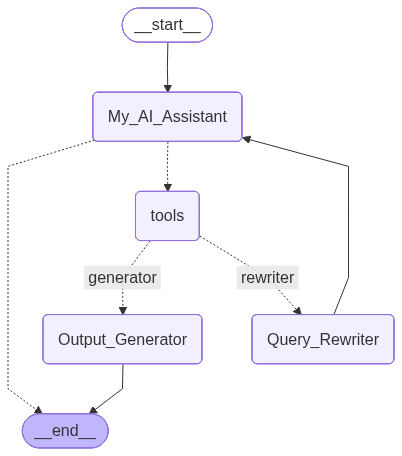

In [118]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [121]:
app.invoke({"messages":[{"role": "user", "content": "Who is the citizen of India according to MEA?"}]})

---CALL AGENT---
this is my message: [HumanMessage(content='Who is the citizen of India according to MEA?', additional_kwargs={}, response_metadata={}, id='0213da58-3845-46a3-9547-c1a999403103')]


INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent "HTTP/1.1 200 OK"
INFO:google_genai.models:AFC is enabled with max remote calls: 10.


message from the grader: [HumanMessage(content='Who is the citizen of India according to MEA?', additional_kwargs={}, response_metadata={}, id='0213da58-3845-46a3-9547-c1a999403103'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'MEA_Retriever', 'arguments': '{"query": "Who is the citizen of India"}'}, '__gemini_function_call_thought_signatures__': {'dca6cdda-3dce-44ea-8bb6-d27e65274fff': 'ErACCq0CAQw51scPvx5yxntkJhqKqFpA2RGd0VEykkIxWDbOHI6i2sG2zdy4pcKZIRbfPb0D4qELiiA1WCxWtt+SI62jdGv37ZQWdACSuSV37PrU0e7fKu5aNaAlWdoR91quNooXP2PI1gcpV7UW9DiMNh7J4o4fkZrkl5GNlX9uaOWSsjBsJpXuZSu/gKmejRvdxJtcnHSMKVNPSWdDXvI16lk/J+z/FSRzZFKSK8QXbQouX0QHU/LZMRDR8LJ4t5U8ieyr2VIhBx90D6KivY1iRJ/F3vMBEf7cuwPFqnK3xCPKXBIGQEoIcEL+gHOgIfKD/tWJpnEr50LAWkNxfK26irOiEe3Eb8OspI9FS5IUswfyt9UC3n3IMZwmrcpN9tyfIXAFLemclMgUmcHmkfdX3Q=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5961-5588-7f92-b3

INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent "HTTP/1.1 200 OK"
INFO:google_genai.models:AFC is enabled with max remote calls: 10.


---DECISION: CONTEXT NOT RELEVANT---
---TRANSFORM QUERY---
here is message from rewrite: [HumanMessage(content='Who is the citizen of India according to MEA?', additional_kwargs={}, response_metadata={}, id='0213da58-3845-46a3-9547-c1a999403103'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'MEA_Retriever', 'arguments': '{"query": "Who is the citizen of India"}'}, '__gemini_function_call_thought_signatures__': {'dca6cdda-3dce-44ea-8bb6-d27e65274fff': 'ErACCq0CAQw51scPvx5yxntkJhqKqFpA2RGd0VEykkIxWDbOHI6i2sG2zdy4pcKZIRbfPb0D4qELiiA1WCxWtt+SI62jdGv37ZQWdACSuSV37PrU0e7fKu5aNaAlWdoR91quNooXP2PI1gcpV7UW9DiMNh7J4o4fkZrkl5GNlX9uaOWSsjBsJpXuZSu/gKmejRvdxJtcnHSMKVNPSWdDXvI16lk/J+z/FSRzZFKSK8QXbQouX0QHU/LZMRDR8LJ4t5U8ieyr2VIhBx90D6KivY1iRJ/F3vMBEf7cuwPFqnK3xCPKXBIGQEoIcEL+gHOgIfKD/tWJpnEr50LAWkNxfK26irOiEe3Eb8OspI9FS5IUswfyt9UC3n3IMZwmrcpN9tyfIXAFLemclMgUmcHmkfdX3Q=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'mod

INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent "HTTP/1.1 200 OK"


---CALL AGENT---
this is my message: [HumanMessage(content='Who is the citizen of India according to MEA?', additional_kwargs={}, response_metadata={}, id='0213da58-3845-46a3-9547-c1a999403103'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'MEA_Retriever', 'arguments': '{"query": "Who is the citizen of India"}'}, '__gemini_function_call_thought_signatures__': {'dca6cdda-3dce-44ea-8bb6-d27e65274fff': 'ErACCq0CAQw51scPvx5yxntkJhqKqFpA2RGd0VEykkIxWDbOHI6i2sG2zdy4pcKZIRbfPb0D4qELiiA1WCxWtt+SI62jdGv37ZQWdACSuSV37PrU0e7fKu5aNaAlWdoR91quNooXP2PI1gcpV7UW9DiMNh7J4o4fkZrkl5GNlX9uaOWSsjBsJpXuZSu/gKmejRvdxJtcnHSMKVNPSWdDXvI16lk/J+z/FSRzZFKSK8QXbQouX0QHU/LZMRDR8LJ4t5U8ieyr2VIhBx90D6KivY1iRJ/F3vMBEf7cuwPFqnK3xCPKXBIGQEoIcEL+gHOgIfKD/tWJpnEr50LAWkNxfK26irOiEe3Eb8OspI9FS5IUswfyt9UC3n3IMZwmrcpN9tyfIXAFLemclMgUmcHmkfdX3Q=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5961-

ValueError: Message dict must contain 'role' and 'content' keys, got {'type': 'text', 'text': 'Based on the original question, the underlying semantic intent is to understand the official legal definition and criteria for Indian citizenship, specifically through the lens of the Indian government\'s foreign affairs and consular guidelines (such as passport eligibility, NRI/OCI status, or dual citizenship rules). \n\nHowever, there is a minor technical inaccuracy in the original question: while the **Ministry of External Affairs (MEA)** handles passports and overseas citizens (OCIs/NRIs), the **Ministry of Home Affairs (MHA)** is the primary authority that defines and administers citizenship laws in India under the Citizenship Act of 1955.\n\nHere are a few ways to formulate an improved, more precise question depending on your specific focus:\n\n### Option 1: If you want to know about general citizenship laws (Correcting the Ministry)\n> "What are the legal criteria for acquiring Indian 

In [124]:
app.invoke({"messages":["who is a current prime minister of india?"]})

---CALL AGENT---
this is my message: [HumanMessage(content='who is a current prime minister of india?', additional_kwargs={}, response_metadata={}, id='b71c9687-4db5-42cb-a9a5-00d7e5fb684a')]


INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent "HTTP/1.1 200 OK"
INFO:google_genai.models:AFC is enabled with max remote calls: 10.


message from the grader: [HumanMessage(content='who is a current prime minister of india?', additional_kwargs={}, response_metadata={}, id='b71c9687-4db5-42cb-a9a5-00d7e5fb684a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "current prime minister of india"}'}, '__gemini_function_call_thought_signatures__': {'e7bfb72a-f07e-452e-ad97-841ad2da7bc1': 'EsgDCsUDAQw51sfZvTATt3MVjqBexOHijBWOl5UHXeG/dlPWwl/zgzMP26ARZZEUdmWxUI0/LBfx575DUyKuGXxKc0WGgxz6V7AB+a+clBMX0MqZ+pQ7xTR3iIF272FrEouQvpMYEaVlnHZztBkjKtAVGvxLzKlpYE9R2V2l0l6ff8k28hnCZbWRZUKnnB0S2Jvi9pc54VK6zFSMBCyoy84fm/tqf1wpWlMP8Gk0ICM2ObMtXjAM18bZEK2ELkNaZjLX9wDQlbBC9zWFHtx9bb7wgJy/igTNPY+YmMi/39jAW7xPJWEennYf3qllJu7gIpDMbs/hqkQRImo3WQ83MBj06MYGT+v1RA9tvAh9LkIS9oLNeDnu3oKztDWH9CsSaFaoz2UyB2bZqU6OX2lXWC4jBQYvFQ1TGrcKB+xZzf1Zl5sWhdePKw+E5b92t/LU74WwUGK6tIVeQuV296mB3OmZqyl6/roafW1V8s/nZ0a7STORQKanewjUUXNvCswhN2qqbo5qzCm9dud62Ese6JJi1C5KknyFYPuHBQwZ7n9RdILFD7LCjl3vHNMvqsQQ5r5J+RLI+

INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.5-flash:generateContent "HTTP/1.1 200 OK"


---DECISION: CONTEXT RELEVANT---
---GENERATE---
here is message from generate: [HumanMessage(content='who is a current prime minister of india?', additional_kwargs={}, response_metadata={}, id='b71c9687-4db5-42cb-a9a5-00d7e5fb684a'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "current prime minister of india"}'}, '__gemini_function_call_thought_signatures__': {'e7bfb72a-f07e-452e-ad97-841ad2da7bc1': 'EsgDCsUDAQw51sfZvTATt3MVjqBexOHijBWOl5UHXeG/dlPWwl/zgzMP26ARZZEUdmWxUI0/LBfx575DUyKuGXxKc0WGgxz6V7AB+a+clBMX0MqZ+pQ7xTR3iIF272FrEouQvpMYEaVlnHZztBkjKtAVGvxLzKlpYE9R2V2l0l6ff8k28hnCZbWRZUKnnB0S2Jvi9pc54VK6zFSMBCyoy84fm/tqf1wpWlMP8Gk0ICM2ObMtXjAM18bZEK2ELkNaZjLX9wDQlbBC9zWFHtx9bb7wgJy/igTNPY+YmMi/39jAW7xPJWEennYf3qllJu7gIpDMbs/hqkQRImo3WQ83MBj06MYGT+v1RA9tvAh9LkIS9oLNeDnu3oKztDWH9CsSaFaoz2UyB2bZqU6OX2lXWC4jBQYvFQ1TGrcKB+xZzf1Zl5sWhdePKw+E5b92t/LU74WwUGK6tIVeQuV296mB3OmZqyl6/roafW1V8s/nZ0a7STORQKanewjUUXNvCswhN2qqbo5qzCm9dud62Es

TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'>